<a href="https://colab.research.google.com/github/flatironinstitute/2026-flatiron-cmb-summer-school/blob/main/notebooks/CMB_Beam_Systematics.ipynb/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMB Beam Systematics
---

Real CMB telescopes do not have perfect, symmetric beams. Imperfections in the optics introduce **beam systematics** that contaminate cosmological measurements. This notebook explores how beam effects manifest in CMB maps and power spectra, covering:

1. **Beam shapes**: Gaussian, Elliptical Gaussian, and Airy disk beams
2. **T → P leakage** (Temperature-to-Polarization): beam sidelobes, beam asymmetry, differential beam shapes
3. **E → B leakage** (mixing of E and B polarization modes): cross-polarization, polarized beam sidelobes, polarized beam asymmetry

We work in the **flat-sky approximation** throughout, following the conventions of the other summer school notebooks. The signal we care most about — primordial B-modes from inflation — is at the level of $r \lesssim 0.01$, so even sub-percent beam systematics can be impactful.

In [1]:
# !python -c "import cmb_modules" || ( \
#     wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/cmb_modules.py && \
#     wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/constants.py \
# )

# !python -c "import camb" || python -m pip install camb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gridspec
from scipy.special import j1
from scipy.ndimage import rotate as ndimage_rotate
from scipy import special


import constants as cs
import cmb_modules

# Import CAMB for theory spectra
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size'] = 12

colors = ["#4477AA", "#EE7733", "#228833", "#EE6677"]

## Make the 2D beam maps and corresponding harmonic transforms of different types of beams
### We consider a Gaussian, an elliptical Gaussian and an Airy function beam

In [3]:
def make_2d_gaussian_beam(N, pix_size, beam_size_fwhm):
    """Circularly-symmetric Gaussian beam in real space.

    Parameters
    ----------
    N            : int    — number of pixels per side
    pix_size     : float  — pixel size in arcminutes
    beam_size_fwhm: float — FWHM in arcminutes

    Returns
    -------
    beam2d : (N,N) ndarray, normalised to unit sum
    """
    sigma = beam_size_fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    inds = np.linspace(-N/2.0 * pix_size, N/2.0 * pix_size, N)
    X, Y = np.meshgrid(inds, inds)
    beam2d = np.exp(-0.5 * (X**2 + Y**2) / sigma**2)
    beam2d /= beam2d.sum()
    return beam2d


def make_2d_elliptical_gaussian_beam(N, pix_size, fwhm_x, fwhm_y, angle_deg=0.0):
    """Elliptical Gaussian beam, optionally rotated.

    Parameters
    ----------
    fwhm_x, fwhm_y : FWHM along the two principal axes (arcmin)
    angle_deg      : rotation angle of the major axis (degrees, CCW)
    """
    sigma_x = fwhm_x / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sigma_y = fwhm_y / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    inds = np.linspace(-N/2.0 * pix_size, N/2.0 * pix_size, N)
    X, Y = np.meshgrid(inds, inds)
    theta = np.radians(angle_deg)
    Xr =  X * np.cos(theta) + Y * np.sin(theta)
    Yr = -X * np.sin(theta) + Y * np.cos(theta)
    beam2d = np.exp(-0.5 * (Xr**2 / sigma_x**2 + Yr**2 / sigma_y**2))
    beam2d /= beam2d.sum()
    return beam2d


def make_2d_airy_beam(N, pix_size, fwhm_ref):
    """Airy disk beam — the diffraction pattern of a circular aperture.

    For a circular aperture of diameter D at wavelength λ the pattern is
        I(r) ∝ [2 J1(π r / r0) / (π r / r0)]²
    where r0 is chosen so that the central lobe FWHM matches fwhm_ref.
    """
    # For an Airy disk, FWHM ≈ 1.028 λ/D; the first zero is at 1.22 λ/D.
    # Numerically: FWHM of Airy ≈ 1.028 * (first-zero radius / 1.22)
    # Simpler: set scale parameter so half-power radius matches Gaussian equivalent
    sigma_ref = fwhm_ref / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    # Empirically match: scale = FWHM_ref / 2.27  (so first sidelobe at ~1.64 × FWHM)
    scale = fwhm_ref / 1.029   # arcmin per unit of J1 argument
    inds = np.linspace(-N/2.0 * pix_size, N/2.0 * pix_size, N)
    X, Y = np.meshgrid(inds, inds)
    r = np.sqrt(X**2 + Y**2)
    x = np.pi * r / scale
    # Avoid division by zero at centre
    with np.errstate(invalid='ignore', divide='ignore'):
        airy = np.where(x == 0, 1.0, (2.0 * j1(x) / x)**2)
    airy /= airy.sum()
    return airy


def beam_function_2d(N, pix_size, beam_type='gaussian', **kwargs):
    """Return a 2D beam array for the requested beam type."""
    if beam_type == 'gaussian':
        return make_2d_gaussian_beam(N, pix_size, kwargs['fwhm'])
    elif beam_type == 'elliptical':
        return make_2d_elliptical_gaussian_beam(
            N, pix_size, kwargs['fwhm_x'], kwargs['fwhm_y'],
            kwargs.get('angle_deg', 0.0))
    elif beam_type == 'airy':
        return make_2d_airy_beam(N, pix_size, kwargs['fwhm'])
    else:
        raise ValueError(f"Unknown beam type: {beam_type}")

Map size        : 16.67° × 16.67°
Pixel size      : 0.50 arcmin
Nominal FWHM    : 30.00 arcmin
Elliptical FWHM : 36.00 × 24.00 arcmin, angle=30.0°
Ellipticity     : ε = 0.200


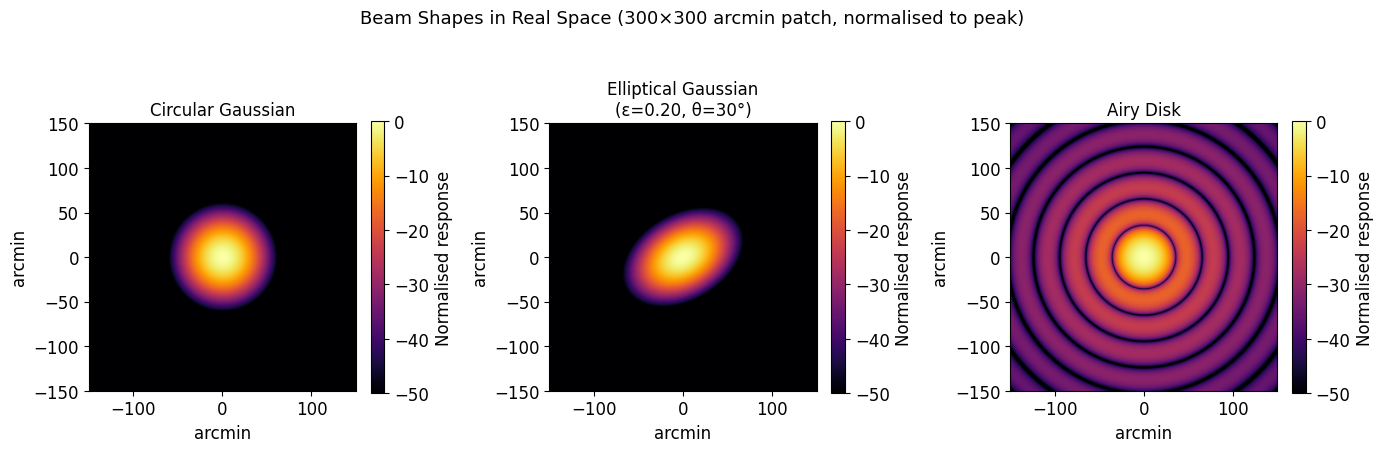

In [4]:

#Map and beam parameters
N         = 2000          # pixels per side
pix_size  = 0.5          # arcmin per pixel
fwhm_nom  = 30             # nominal beam FWHM in arcmin
# fwhm_nom  = 1.4             # nominal beam FWHM in arcmin
patch_size = 300           # map size in arcmin

# Elliptical beam: major axis 20% larger, minor 20% smaller
fwhm_x    = fwhm_nom * 1.2
fwhm_y    = fwhm_nom * 0.8
ell_angle = 30.0         # degrees CCW from x-axis

print(f"Map size        : {N*pix_size/60:.2f}° × {N*pix_size/60:.2f}°")
print(f"Pixel size      : {pix_size:.2f} arcmin")
print(f"Nominal FWHM    : {fwhm_nom:.2f} arcmin")
print(f"Elliptical FWHM : {fwhm_x:.2f} × {fwhm_y:.2f} arcmin, angle={ell_angle}°")
print(f"Ellipticity     : ε = {(fwhm_x - fwhm_y)/(fwhm_x + fwhm_y):.3f}")

# Build the three beams
beam_gauss  = make_2d_gaussian_beam(N, pix_size, fwhm_nom)
beam_ellip  = make_2d_elliptical_gaussian_beam(N, pix_size, fwhm_x, fwhm_y, ell_angle)
beam_airy   = make_2d_airy_beam(N, pix_size, fwhm_nom)

# Plot the 2D maps
half = int(patch_size/ pix_size // 2)  # pixels for ±7.5 arcmin
cx   = N // 2
sl   = slice(cx - half, cx + half)

vmax = beam_gauss[cx, cx]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
titles = ['Circular Gaussian', 'Elliptical Gaussian\n(ε=0.20, θ=30°)', 'Airy Disk']
beams  = [beam_gauss, beam_ellip, beam_airy]

for ax, beam, title in zip(axes, beams, titles):
    extent = [-half * pix_size, half * pix_size] * 2
    im = ax.imshow(10*np.log10(beam[sl, sl] / np.nanmax(beam[sl,sl])), origin='lower', cmap='inferno',
                   vmin=-50, vmax=0,
                   extent=[-half*pix_size, half*pix_size,
                           -half*pix_size, half*pix_size])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('arcmin')
    ax.set_ylabel('arcmin')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Normalised response')

plt.suptitle('Beam Shapes in Real Space ({}×{} arcmin patch, normalised to peak)'.format(patch_size,patch_size),
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

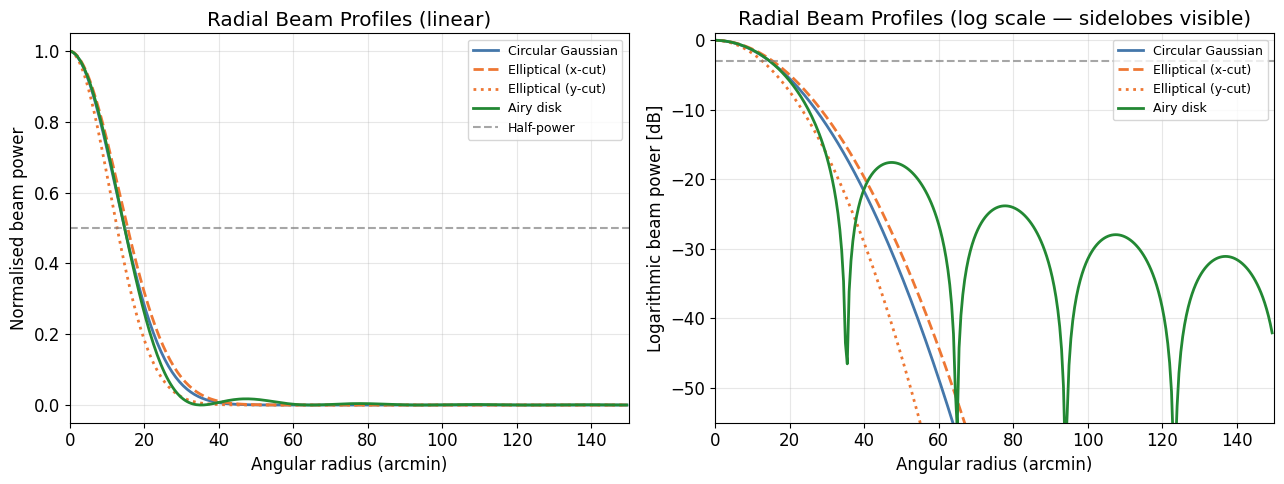


Key observation: The Airy beam has significant sidelobes (rings) that the Gaussian model misses entirely.
The elliptical beam differs between x- and y-cuts, breaking azimuthal symmetry.


In [5]:
# Radial beam profiles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_pix  = np.arange(0, half)
r_amin = r_pix * pix_size

# Take cuts through the centre pixel
def radial_cut(beam, cx):
    return beam[cx, cx:cx + half] / beam[cx, cx]

ax = axes[0]
ax.plot(r_amin, radial_cut(beam_gauss, cx), label='Circular Gaussian', lw=2, color=colors[0])
ax.plot(r_amin, radial_cut(beam_ellip, cx), label='Elliptical (x-cut)', lw=2, color=colors[1], ls='--')
# for elliptical: also the y-cut
ax.plot(r_amin, beam_ellip[cx:cx+half, cx] / beam_ellip[cx,cx],
        label='Elliptical (y-cut)', lw=2, color=colors[1], ls=':')
ax.plot(r_amin, radial_cut(beam_airy, cx), label='Airy disk', lw=2, color=colors[2])
ax.axhline(0.5, color='grey', ls='--', alpha=0.7, label='Half-power')
ax.set_xlabel('Angular radius (arcmin)')
ax.set_ylabel('Normalised beam power')
ax.set_title('Radial Beam Profiles (linear)')
ax.legend(fontsize=9); ax.set_xlim(0, 5*fwhm_nom); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r_amin, 10*np.log10(np.maximum(radial_cut(beam_gauss, cx), 1e-6)), label='Circular Gaussian', lw=2, color=colors[0])
ax.plot(r_amin, 10*np.log10(np.maximum(radial_cut(beam_ellip, cx), 1e-6)), label='Elliptical (x-cut)', lw=2, color=colors[1], ls='--')
ax.plot(r_amin, 10*np.log10(np.maximum(beam_ellip[cx:cx+half, cx] / beam_ellip[cx,cx], 1e-6)),
            label='Elliptical (y-cut)', lw=2, color=colors[1], ls=':')
ax.plot(r_amin,10*np.log10(np.maximum(radial_cut(beam_airy, cx), 1e-6)), label='Airy disk', lw=2, color=colors[2])
ax.axhline(-3, color='grey', ls='--', alpha=0.7)
ax.set_xlabel('Angular radius (arcmin)')
ax.set_ylabel('Logarithmic beam power [dB]')
ax.set_title('Radial Beam Profiles (log scale — sidelobes visible)')
ax.legend(fontsize=9); ax.set_xlim(0, 5*fwhm_nom); ax.set_ylim(-55, 1); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("\nKey observation: The Airy beam has significant sidelobes (rings) that the Gaussian model misses entirely.")
print("The elliptical beam differs between x- and y-cuts, breaking azimuthal symmetry.")

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
/var/folders/pk/xl4598515pb7q2jfw1tdzyr00000gn/T/ipykernel_41447/1789679781.py:63: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f'Beam Transfer Function B($\ell$) [{yscale}]')


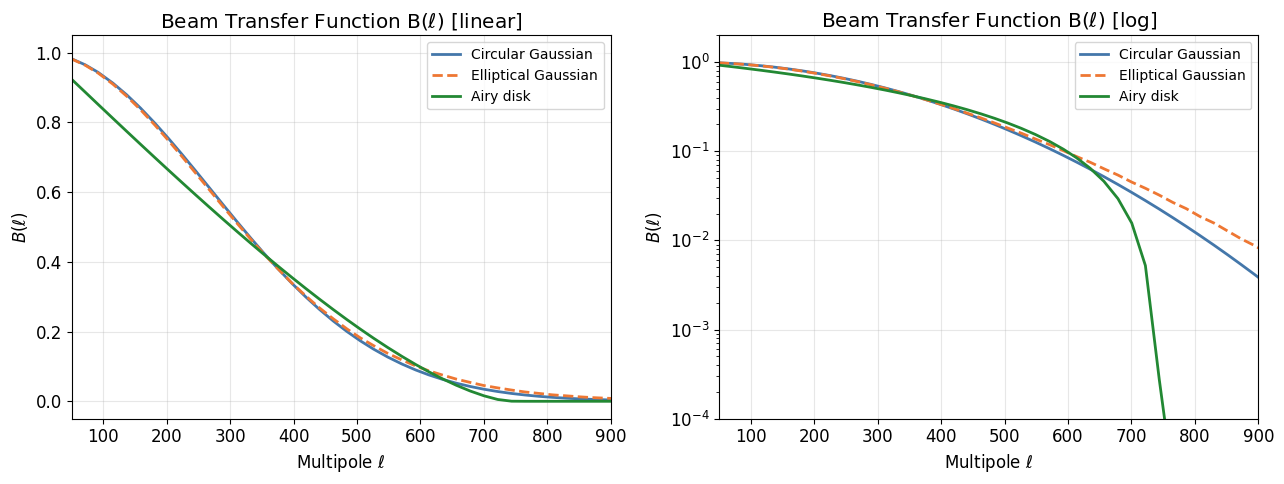

In [6]:
# Beam Transfer Functions B(ℓ)
def make_ell_grid(N, pix_size):
    """2D multipole grid for an NxN map, pix_size in arcmin."""
    pix_size_rad = pix_size * np.pi / (180.0 * 60.0)

    fx = np.fft.fftshift(np.fft.fftfreq(N, d=pix_size_rad))
    fy = np.fft.fftshift(np.fft.fftfreq(N, d=pix_size_rad))
    FX, FY = np.meshgrid(fx, fy)

    ell_x = 2.0 * np.pi * FX
    ell_y = 2.0 * np.pi * FY
    L = np.sqrt(ell_x**2 + ell_y**2)
    return ell_x, ell_y, L


def azimuthal_average(arr2d, L):
    """Azimuthal average of a centered 2D array."""
    N = arr2d.shape[0]
    cy, cx = N // 2, N // 2

    y, x = np.indices(arr2d.shape)
    r_pix = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_int = r_pix.astype(int)

    sum_per_bin = np.bincount(r_int.ravel(), weights=arr2d.ravel())
    n_per_bin   = np.bincount(r_int.ravel())

    valid = n_per_bin > 0
    val = sum_per_bin[valid] / n_per_bin[valid]

    sumL_per_bin = np.bincount(r_int.ravel(), weights=L.ravel())
    ell_c = sumL_per_bin[valid] / n_per_bin[valid]

    return ell_c, val


def compute_beam_transfer_function(beam2d, pix_size):
    """Compute smooth azimuthally averaged B(ell) from a 2D real-space beam."""
    B2d = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(beam2d)))
    B2d = np.real(B2d)

    center = B2d.shape[0] // 2
    B2d /= B2d[center, center]

    L = make_ell_grid(beam2d.shape[0], pix_size)[2]
    ell, Bl = azimuthal_average(B2d, L)

    return ell, Bl, B2d, L


ell_bl, Bl_gauss, B2d_g, L_g = compute_beam_transfer_function(beam_gauss, pix_size)
ell_bl, Bl_ellip, B2d_e, L_e = compute_beam_transfer_function(beam_ellip, pix_size)
ell_bl, Bl_airy, B2d_a, L_a = compute_beam_transfer_function(beam_airy, pix_size)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.plot(ell_bl, Bl_gauss/np.nanmax(Bl_gauss), label='Circular Gaussian', lw=2, color=colors[0])
    ax.plot(ell_bl, Bl_ellip/np.nanmax(Bl_ellip), label='Elliptical Gaussian', lw=2, color=colors[1], ls='--')
    ax.plot(ell_bl, Bl_airy/np.nanmax(Bl_airy),  label='Airy disk', lw=2, color=colors[2])
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$B(\ell)$')
    ax.set_title(f'Beam Transfer Function B($\ell$) [{yscale}]')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    ax.set_xlim(50, 2.5*180/(fwhm_nom/60))
    if yscale == 'log':
        ax.set_yscale('log')
        ax.set_ylim(1e-4, 2)

plt.tight_layout(); plt.show()

## Get theory power spectra TT, EE, BB, TE as in previous notebooks using camb

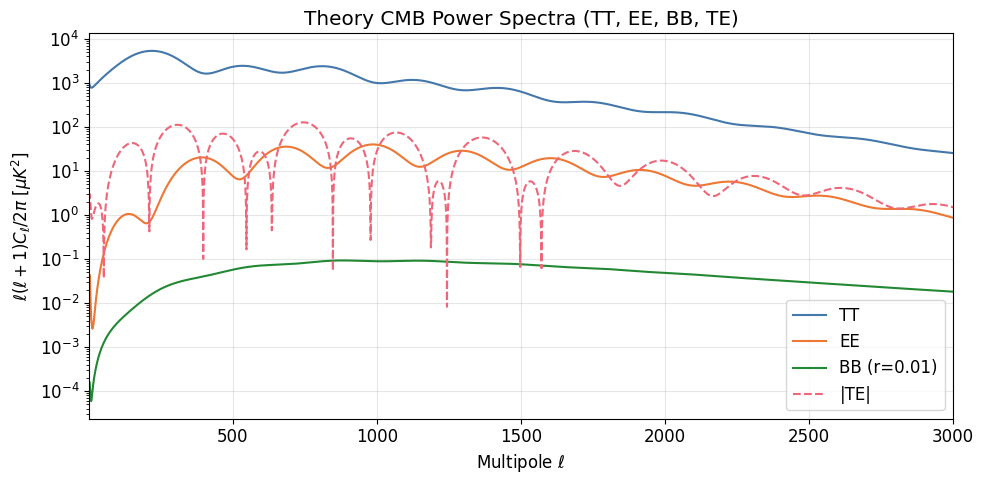

In [7]:
import camb
def get_theory_spectra(lmax=3000, r_tensor=0.01):
    """Return ell, TT, EE, BB, TE theory spectra in uK².
    """
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=67.4, ombh2=0.022, omch2=0.122,
                        mnu=0.06, omk=0, tau=0.06)
    pars.InitPower.set_params(As=2e-9, ns=0.965, r=r_tensor)
    pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    pars.WantTensors = True
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    tot = powers['total']   # returns TT EE BB TE
    ell = np.arange(tot.shape[0])
    return ell, tot[:, 0], tot[:, 1], tot[:, 2], tot[:, 3]


ell_th, TT_th, EE_th, BB_th, TE_th = get_theory_spectra(lmax=5000, r_tensor=0.01)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(ell_th[2:], TT_th[2:], label='TT', color=colors[0])
ax.semilogy(ell_th[2:], EE_th[2:], label='EE', color=colors[1])
ax.semilogy(ell_th[2:], BB_th[2:], label='BB (r=0.01)', color=colors[2])
ax.semilogy(ell_th[2:], np.abs(TE_th[2:]), label='|TE|', color=colors[3], ls='--')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$ [$\mu K^2$]')
ax.set_title('Theory CMB Power Spectra (TT, EE, BB, TE)')
ax.legend(); ax.set_xlim(2, 3000); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Make a CMB map as before and convolve with the different types of beams:


CMB T rms   =  101.29 μK
CMB Q rms   =   4.464 μK    U rms = 4.429 μK
input E rms =   6.275 μK    B rms = 0.402 μK   (r = 0.01)


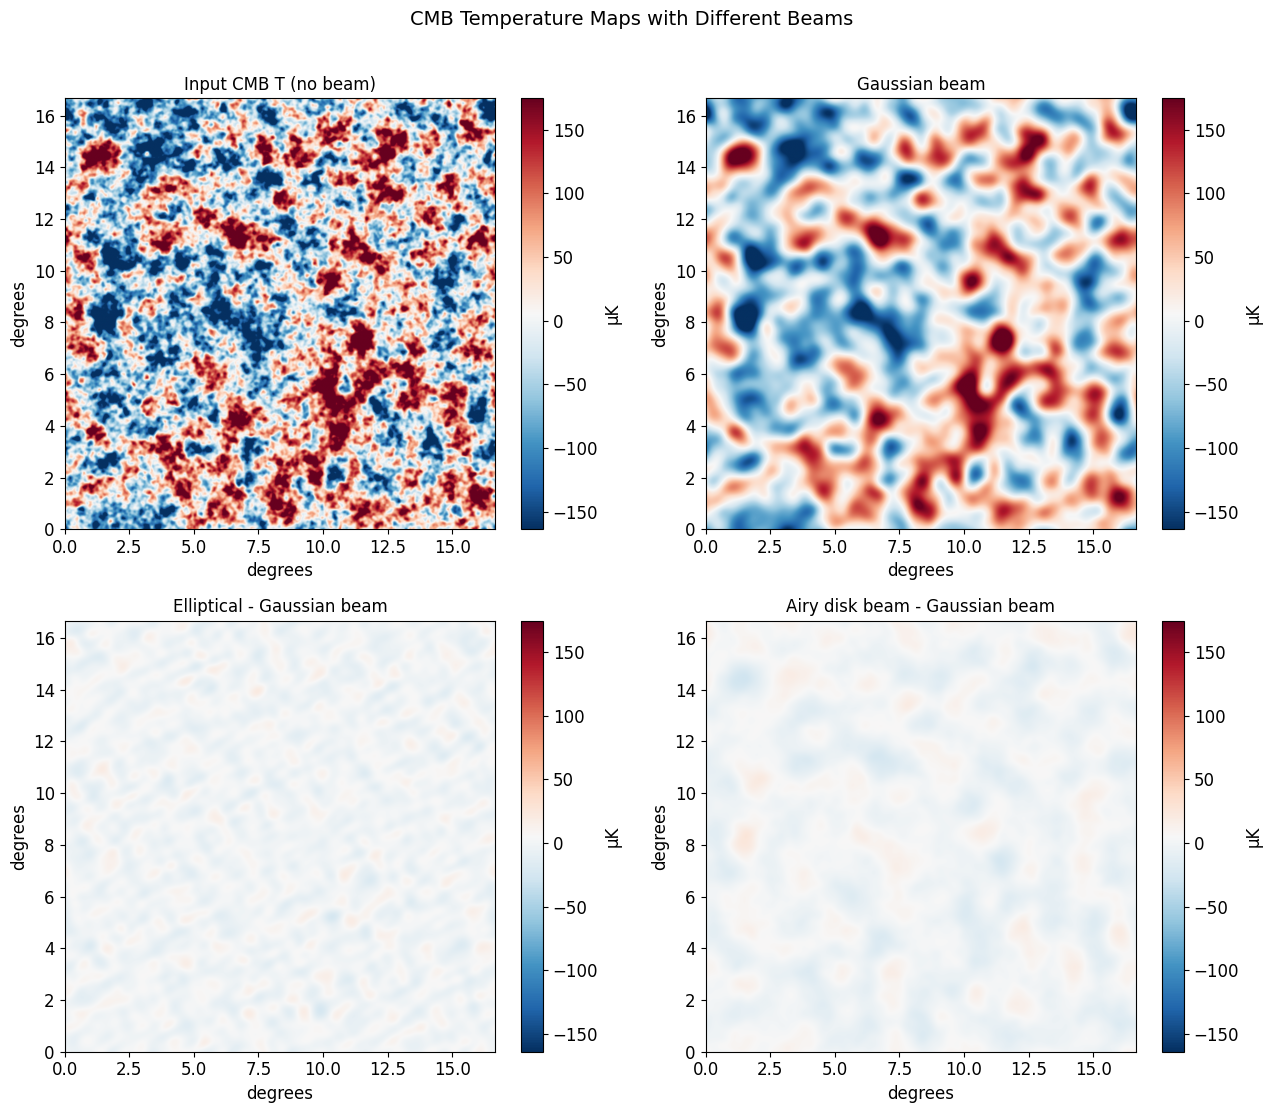

In [8]:
# Generate the CMB sky: T, Q, U (plus the input E, B)

np.random.seed(2024)
cmb_T, Q_sky, U_sky, E_in, B_in = cmb_modules.make_CMB_maps(
    N, pix_size, ell_th, TT_th, EE_th, TE_th, BB_th)

print(f"CMB T rms   = {cmb_T.std():7.2f} μK")
print(f"CMB Q rms   = {Q_sky.std():7.3f} μK    U rms = {U_sky.std():.3f} μK")
print(f"input E rms = {E_in.std():7.3f} μK    B rms = {B_in.std():.3f} μK   (r = 0.01)")


# Convolve with each beam

# Same as before but taking as input the beam map created already
def convolve_map_with_beam(map2d, beam2d):
    """Convolve a 2D map with a 2D beam using FFTs."""
    FT_map  = np.fft.fft2(np.fft.fftshift(map2d))
    FT_beam = np.fft.fft2(np.fft.fftshift(beam2d))
    return np.fft.ifftshift(np.fft.ifft2(FT_map * FT_beam).real)

T_gauss = convolve_map_with_beam(cmb_T, beam_gauss)
T_ellip = convolve_map_with_beam(cmb_T, beam_ellip)
T_airy  = convolve_map_with_beam(cmb_T, beam_airy)

# Plot the maps
vmin_T, vmax_T = np.percentile(T_gauss, [1, 99])

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
titles = ['Input CMB T (no beam)', 'Gaussian beam', 'Elliptical - Gaussian beam', 'Airy disk beam - Gaussian beam']
maps   = [cmb_T, T_gauss, T_ellip-T_gauss, T_airy-T_gauss]
map_size_deg = N * pix_size / 60.0

for ax, m, title in zip(axes.ravel(), maps, titles):
    im = ax.imshow(m, origin='lower', cmap='RdBu_r',
                   vmin=vmin_T, vmax=vmax_T,
                   extent=[0, map_size_deg, 0, map_size_deg])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('degrees')
    ax.set_ylabel('degrees')
    plt.colorbar(im, ax=ax, fraction=0.046, label='μK')

plt.suptitle('CMB Temperature Maps with Different Beams', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [9]:
Amplitude_of_Sources = cs.Amplitude_of_Sources

PSMap_one = cmb_modules.Poisson_source_component(N, pix_size, 10, Amplitude_of_Sources)

psource_gauss = convolve_map_with_beam(PSMap_one, beam_gauss)
psource_ellip = convolve_map_with_beam(PSMap_one, beam_ellip)
psource_airy  = convolve_map_with_beam(PSMap_one, beam_airy)

Number of sources required:  10


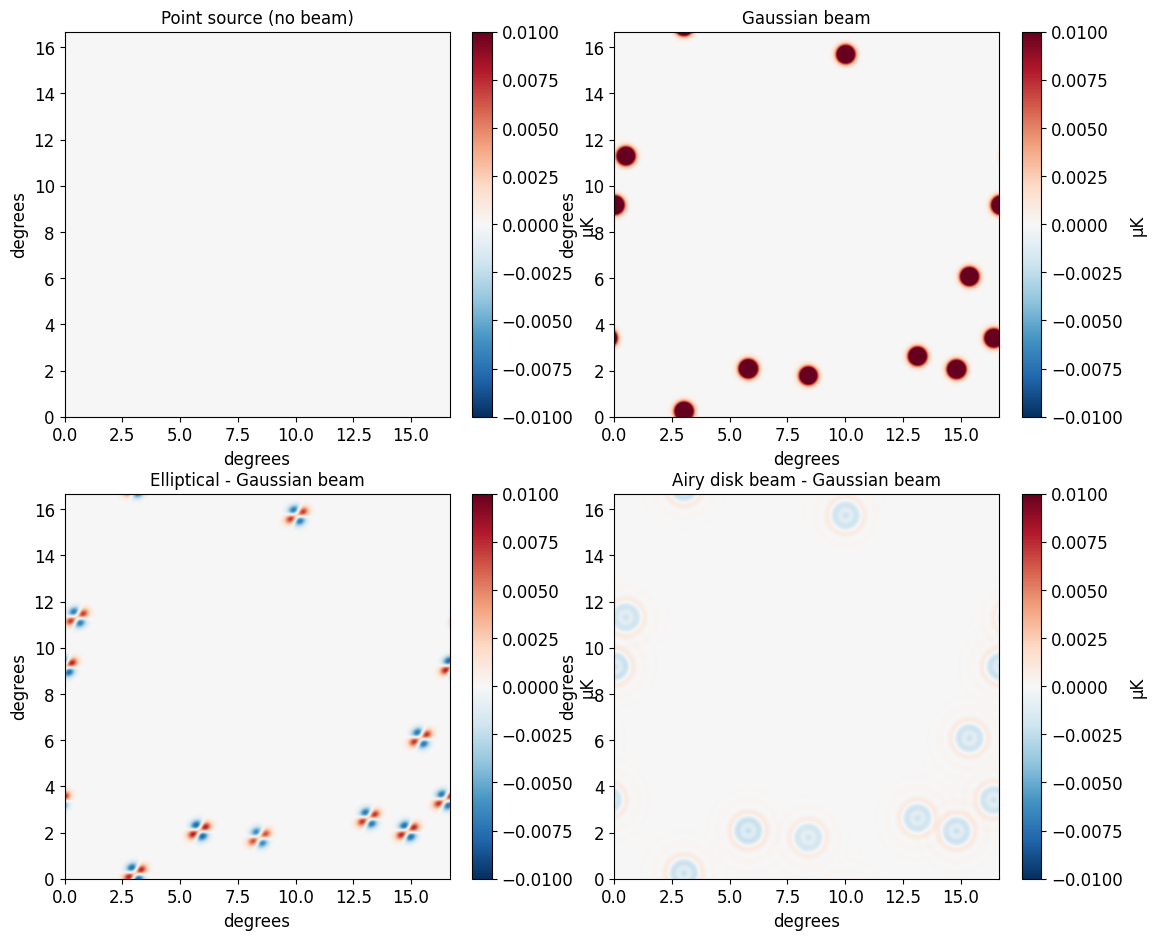

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
titles = ['Point source (no beam)', 'Gaussian beam', 'Elliptical - Gaussian beam', 'Airy disk beam - Gaussian beam']
maps   = [PSMap_one, psource_gauss, psource_ellip-psource_gauss, psource_airy-psource_gauss]
map_size_deg = N * pix_size / 60.0

for ax, m, title in zip(axes.ravel(), maps, titles):
    im = ax.imshow(m, origin='lower', cmap='RdBu_r',
                   vmin=-0.01, vmax=0.01,
                   extent=[0, map_size_deg, 0, map_size_deg])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('degrees')
    ax.set_ylabel('degrees')
    plt.colorbar(im, ax=ax, fraction=0.046, label='μK')

## <font color='red'>**EXERCISE**: </font>  
##### Make and plot the power spectra of the beam-convolved CMB map with a Gaussian, elliptical Gaussian and Airy beam and compare to the original power spectra.

In [11]:
T_gauss.shape
N

2000

In [12]:
delta_ell = 20
ell_max = 3000
ell, Cl_gauss = cmb_modules.calculate_2d_spectrum(T_gauss, T_gauss, delta_ell, ell_max, pix_size, N)
ell, Cl_ellip = cmb_modules.calculate_2d_spectrum(T_ellip, T_ellip, delta_ell, ell_max, pix_size, N)
ell, Cl_airy = cmb_modules.calculate_2d_spectrum(T_airy, T_airy, delta_ell, ell_max, pix_size, N)
# Beam unconvolved power spectra
ell, Cl_unconvolved = cmb_modules.calculate_2d_spectrum(cmb_T, cmb_T, delta_ell, ell_max, pix_size, N)

(1e-06, 5)

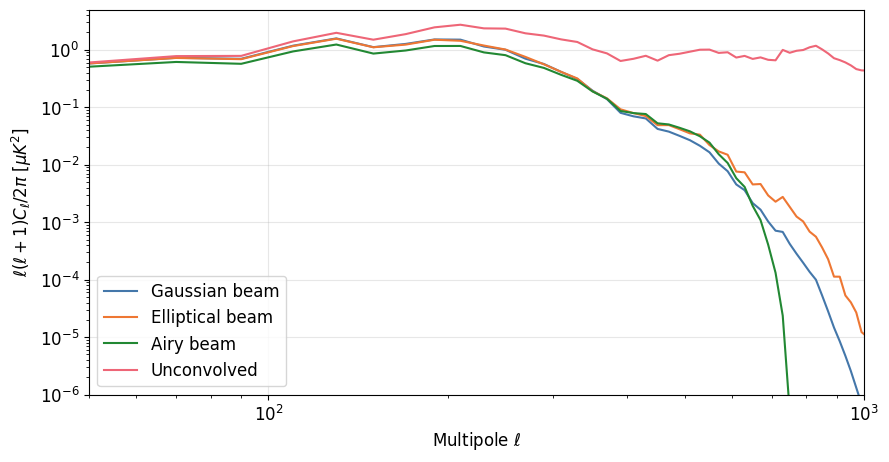

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(ell, ell * (ell + 1) * Cl_gauss / 2 / np.pi, label='Gaussian beam', color=colors[0])
ax.loglog(ell, ell * (ell + 1) * Cl_ellip / 2 / np.pi, label='Elliptical beam', color=colors[1])
ax.loglog(ell, ell * (ell + 1) * Cl_airy / 2 / np.pi, label='Airy beam', color=colors[2])
ax.loglog(ell, ell * (ell + 1) * Cl_unconvolved / 2 / np.pi, label='Unconvolved', color=colors[3])
ax.legend(); ax.set_xlim(2, 3000); ax.grid(True, alpha=0.3)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$ [$\mu K^2$]')
ax.set_xlim(50, 1000)
ax.set_ylim(1e-6, 5)

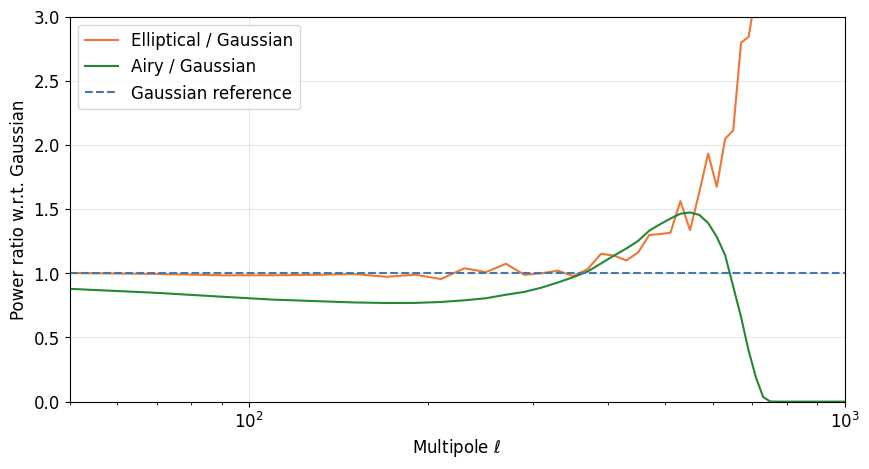

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
# Compute spectra with normalization

# Plot the ratio w.r.t. Gaussian beam
ax.plot(ell, Cl_ellip/ Cl_gauss, label='Elliptical / Gaussian', color=colors[1])
ax.plot(ell, Cl_airy/ Cl_gauss, label='Airy / Gaussian', color=colors[2])
ax.axhline(1.0, color=colors[0], linestyle='--', label='Gaussian reference')

ax.set_xscale('log')
ax.legend()
ax.set_xlim(50, 1000)
ax.set_ylim(0,3)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'Power ratio w.r.t. Gaussian')
ax.grid(True, alpha=0.3)

## T-to-P leakage: Beam sidelobes

A real beam also has **sidelobes**: low-amplitude responses far from
the pointing centre. They pick up bright temperature from patches of sky offset
from where the detector is nominally looking (bright galaxy, mountains, etc.). Because that extra temperature is
not described by the assumed beam, the temperature you actually record differs
from the temperature the code expects. That difference,

$$\delta T \;=\; (B_{\rm real} - B_{\rm assumed}) * T_{\rm sky},$$

is a temperature-shaped residual the solver has no place for — it has
already fit the temperature with the modelled beam — so it gets absorbed into the
$Q/U$ solution. Temperature has leaked into polarization. Pair-differencing helps mitigating the leakage from far sidelobes as compared to per-detector solving.

Important notes to remember:

- Since $T \gg P$, even a sub-percent beam error acts on
  a signal ~100× larger than the target, so the spurious polarization can compete with or
  exceed the real $E$/$B$ signal.
- The leakage tracks the temperature power spectrum, so it
  contaminates a wide range of $\ell$ rather than a single scale.

##### *** For simplicity, we project the leakage onto one linear-polarization component, Q, as a proxy for polarization contamination ***

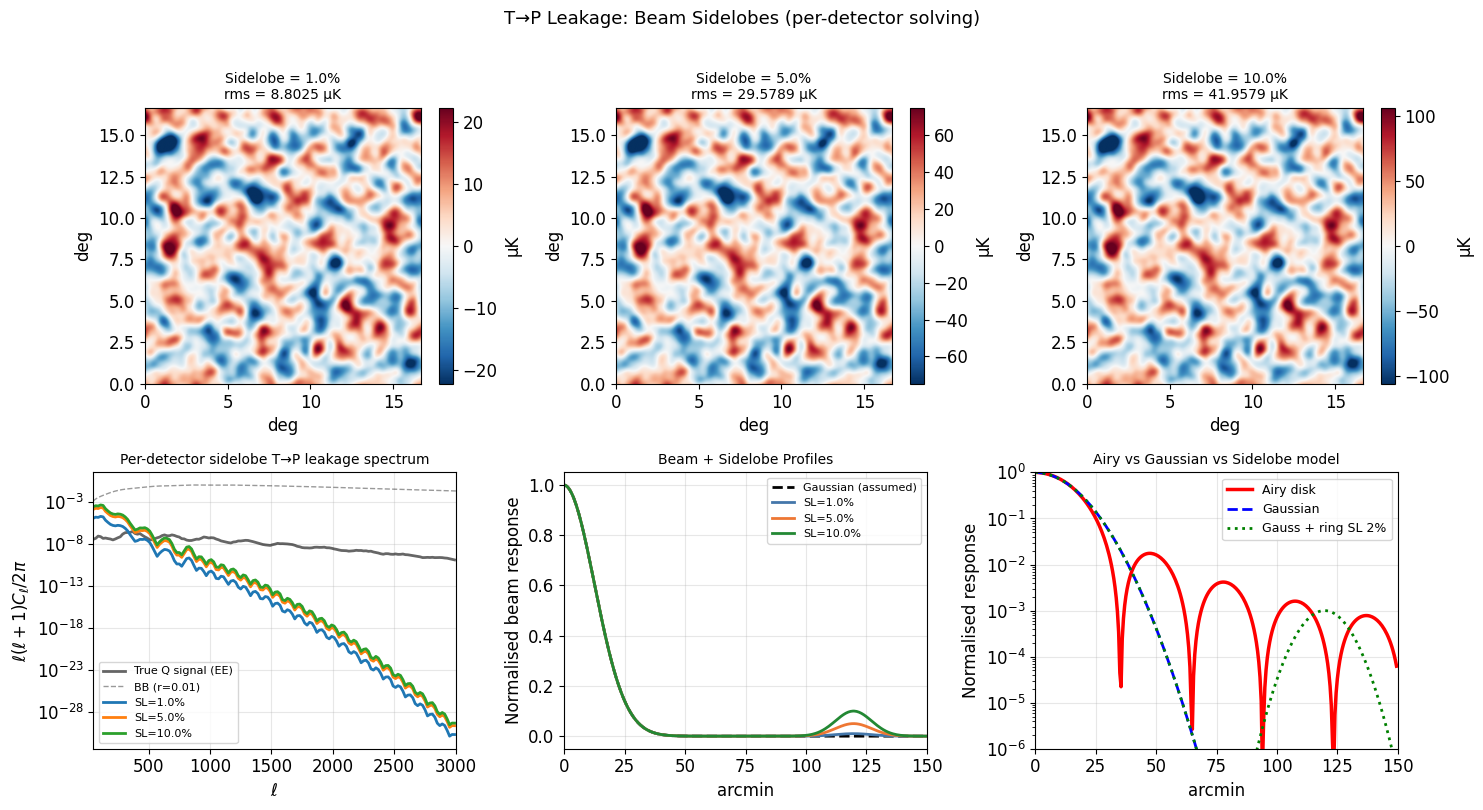

per-detector leakage rms (μK): {'1.0%': 8.8025, '5.0%': 29.5789, '10.0%': 41.9579}


In [15]:
def make_beam_with_sidelobe(N, pix_size, fwhm, sidelobe_frac, sidelobe_radius_fwhm=4.0):
    """Gaussian main beam + a ring sidelobe at a given angular offset.

    Parameterised by:
      sidelobe_frac         : sidelobe peak amplitude relative to main beam
      sidelobe_radius_fwhm  : angular radius of sidelobe ring, in units of FWHM
    """
    beam_main = make_2d_gaussian_beam(N, pix_size, fwhm)
    sigma_sl = fwhm / (2. * np.sqrt(2. * np.log(2.)))
    # The physical (angular) radius at which the sidelobe ring sits
    r_sl = sidelobe_radius_fwhm * fwhm
    inds = np.linspace(-N/2.0 * pix_size, N/2.0 * pix_size, N)
    X, Y = np.meshgrid(inds, inds)
    r = np.sqrt(X**2 + Y**2)
    # Gaussian sidelobe
    ring = np.exp(-0.5 * ((r - r_sl) / (fwhm/4.))**2)
    ring /= ring.max()
    #Adds the ring onto the main beam. The ring is scaled by
    # sidelobe_frac * beam_main.max()
    beam_total = beam_main + sidelobe_frac * ring * beam_main.max()
    beam_total /= beam_total.sum()
    return beam_total

# Sidelobe fractions to explore
sidelobe_fracs = [0.01, 0.05, 0.1]   # 1%, 5%, 10% sidelobe

# Fraction of the temperature residual that ends up in the Q(/U) estimate.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

P_leak_sl = {}

# What the pipeline assumes a detector sees:
beam_nom = make_2d_gaussian_beam(N, pix_size, fwhm_nom)
T_nom = convolve_map_with_beam(cmb_T, beam_nom)

for j, sl_frac in enumerate(sidelobe_fracs):
    # The real beam of this detector (gaussian + unmodelled sidelobe):
    beam_det = make_beam_with_sidelobe(N, pix_size, fwhm_nom, sl_frac)

    T_obs = convolve_map_with_beam(cmb_T, beam_det)   # what the detector actually measures
    # per-detector T->P leakage: the residual the map-maker can't separate from polarisation
    P_leak_sl[sl_frac] = T_obs - T_nom

#Here we assumed all leakage goes to Q but the above is a scalar residual and that
# can only be the case at psi=0. See function below for completeness. This is the
# simplest case.

#def eb_leakage_from_T(res, psi=0.0):
#     Q_leak = res * np.cos(2*psi)
#     U_leak = res * np.sin(2*psi)
#     Qf, Uf = np.fft.fft2(Q_leak), np.fft.fft2(U_leak)
#     Ef =  Qf*np.cos(2*phi) + Uf*np.sin(2*phi)
#     Bf = -Qf*np.sin(2*phi) + Uf*np.cos(2*phi)
#     return np.fft.ifft2(Ef).real, np.fft.ifft2(Bf).real

for j, sl_frac in enumerate(sidelobe_fracs):

    vscale = np.percentile(np.abs(P_leak_sl[sl_frac]), 99)
    # vscale = 0.2
    im = axes[0, j].imshow(P_leak_sl[sl_frac], origin='lower', cmap='RdBu_r',
                           vmin=-vscale, vmax=vscale,
                           extent=[0, N*pix_size/60, 0, N*pix_size/60])
    axes[0, j].set_title(f'Sidelobe = {sl_frac*100:.1f}%\nrms = {P_leak_sl[sl_frac].std():.4f} μK', fontsize=10)
    axes[0, j].set_xlabel('deg'); axes[0, j].set_ylabel('deg')
    plt.colorbar(im, ax=axes[0, j], fraction=0.046, label='μK')

# # Power spectra
# ell_ee, cl_ee = get_ps(Q_sky)  # true E-mode signal in Q since we used Q as a
#                                # proxy for the temperature contamination
ell_ee, cl_ee = cmb_modules.calculate_2d_spectrum(Q_sky, Q_sky, delta_ell, ell_max, pix_size, N)

ax_sl1 = axes[1, 0]
ax_sl1.semilogy(ell_ee, cl_ee, 'k-', lw=2, label='True Q signal (EE)', alpha=0.6)
ax_sl1.semilogy(ell_th[2:], BB_th[2:], 'k--', lw=1, alpha=0.4, label='BB (r=0.01)')
for sl_frac in sidelobe_fracs:
    # ell_sl, cl_sl = get_ps(P_leak_sl[sl_frac])
    ell_sl, cl_sl = cmb_modules.calculate_2d_spectrum(P_leak_sl[sl_frac], P_leak_sl[sl_frac], delta_ell, ell_max, pix_size, N)
    ax_sl1.semilogy(ell_sl, cl_sl, lw=2, label=f'SL={sl_frac*100:.1f}%')
ax_sl1.set_xlabel(r'$\ell$'); ax_sl1.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
ax_sl1.set_title('Per-detector sidelobe T→P leakage spectrum', fontsize=10)
ax_sl1.legend(fontsize=8); ax_sl1.grid(True, alpha=0.3); ax_sl1.set_xlim(50, 3000)

fig.subplots_adjust(wspace=0.3, hspace=0.5)


# # Beam profiles
r_amin = r_pix * pix_size
ax_sl2 = axes[1, 1]
ax_sl2.plot(r_amin, np.maximum(radial_cut(beam_gauss, cx), 1e-7), 'k--', lw=2, label='Gaussian (assumed)')
for i,sl_frac in enumerate(sidelobe_fracs):
    bsl = make_beam_with_sidelobe(N, pix_size, fwhm_nom, sl_frac)
    ax_sl2.plot(r_amin, np.maximum(radial_cut(bsl, cx), 1e-7),
                    lw=2, label=f'SL={sl_frac*100:.1f}%', color=colors[i])
ax_sl2.set_xlabel('arcmin'); ax_sl2.set_ylabel('Normalised beam response')
ax_sl2.set_title('Beam + Sidelobe Profiles', fontsize=10)
ax_sl2.legend(fontsize=8); ax_sl2.grid(True, alpha=0.3); ax_sl2.set_xlim(0, 5*fwhm_nom)

# # Compare Airy vs sidelobe
ax_sl3 = axes[1, 2]
ax_sl3.semilogy(r_amin, np.maximum(radial_cut(beam_airy, cx), 1e-7), 'r-', lw=2.5, label='Airy disk')
ax_sl3.semilogy(r_amin, np.maximum(radial_cut(beam_gauss, cx), 1e-7), 'b--', lw=2, label='Gaussian')
bsl2 = make_beam_with_sidelobe(N, pix_size, fwhm_nom, 0.001)
ax_sl3.semilogy(r_amin, np.maximum(radial_cut(bsl2, cx), 1e-7), 'g:', lw=2, label='Gauss + ring SL 2%')
ax_sl3.set_xlabel('arcmin'); ax_sl3.set_ylabel('Normalised response')
ax_sl3.set_title('Airy vs Gaussian vs Sidelobe model', fontsize=10)
ax_sl3.legend(fontsize=9); ax_sl3.grid(True, alpha=0.3); ax_sl3.set_ylim(10e-07,10e-01); ax_sl3.set_xlim(0, 5*fwhm_nom)

plt.suptitle('T→P Leakage: Beam Sidelobes (per-detector solving)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("per-detector leakage rms (μK):",
      {f"{k*100:.1f}%": round(v.std(), 4) for k, v in P_leak_sl.items()})

## T-to-P leakage: Beam Asymmetry

For a single detector the data model gives:

$$d(\psi) = T + Q\cos 2\psi + U\sin 2\psi.$$

With an asymmetric beam, the signal actually delivered at angle ψ is the
temperature convolved with the beam **rotated to ψ**, $T \star B_\psi$. The
map-maker solves the per-pixel linear system for $(T,Q,U)$:
$\hat{m} = (A^\top A)^{-1} A^\top d$ with rows $A_i = [1,\cos 2\psi_i,\sin 2\psi_i]$.
For uniform angle coverage this reduces to projecting the timestream onto
$1,\cos 2\psi,\sin 2\psi$. This will improve the conditioning of the map but will not remove the angle dependency in the temperature data.

The map-maker will interpret the angle-dependent temperature signal as polarized sky. Crucially — unlike the pair-differencing case - this leakage does not average down as more scan angles are added,
because it is coherent with the $\cos 2\psi/\sin 2\psi$ templates. Suppressing it
requires deprojection or beam-matched map-making, not just uniform angle coverage.

We estimate the Q,U leakage signal from a pure T sky doing a discrete sum over observed angles
$$
\hat{Q} = \frac{2}{n_{\text{angles}}} \sum_i d_i \cos(2\psi_i)
$$

$$
\hat{U} = \frac{2}{n_{\text{angles}}} \sum_i d_i \sin(2\psi_i)
$$

## <font color='red'>**EXERCISES**: </font>  

##### 1. Estimate and plot the leakage rms vs number of observed angles (add to 4th subplot).
##### 2. Estimate and plot the leakage rms vs ellipticity (add to 5th subplot).

baseline:


  computing baseline: n_angles=20, eps=0.20


exercise 1: rms vs n_angles


  computing ex1 n=3: n_angles=3, eps=0.20


  computing ex1 n=5: n_angles=5, eps=0.20


...

exercise 2: rms vs ellipticity


  computing ex2 eps=0.00: n_angles=20, eps=0.00


  computing ex2 eps=0.05: n_angles=20, eps=0.05


  computing ex2 eps=0.10: n_angles=20, eps=0.10


  computing ex2 eps=0.15: n_angles=20, eps=0.15


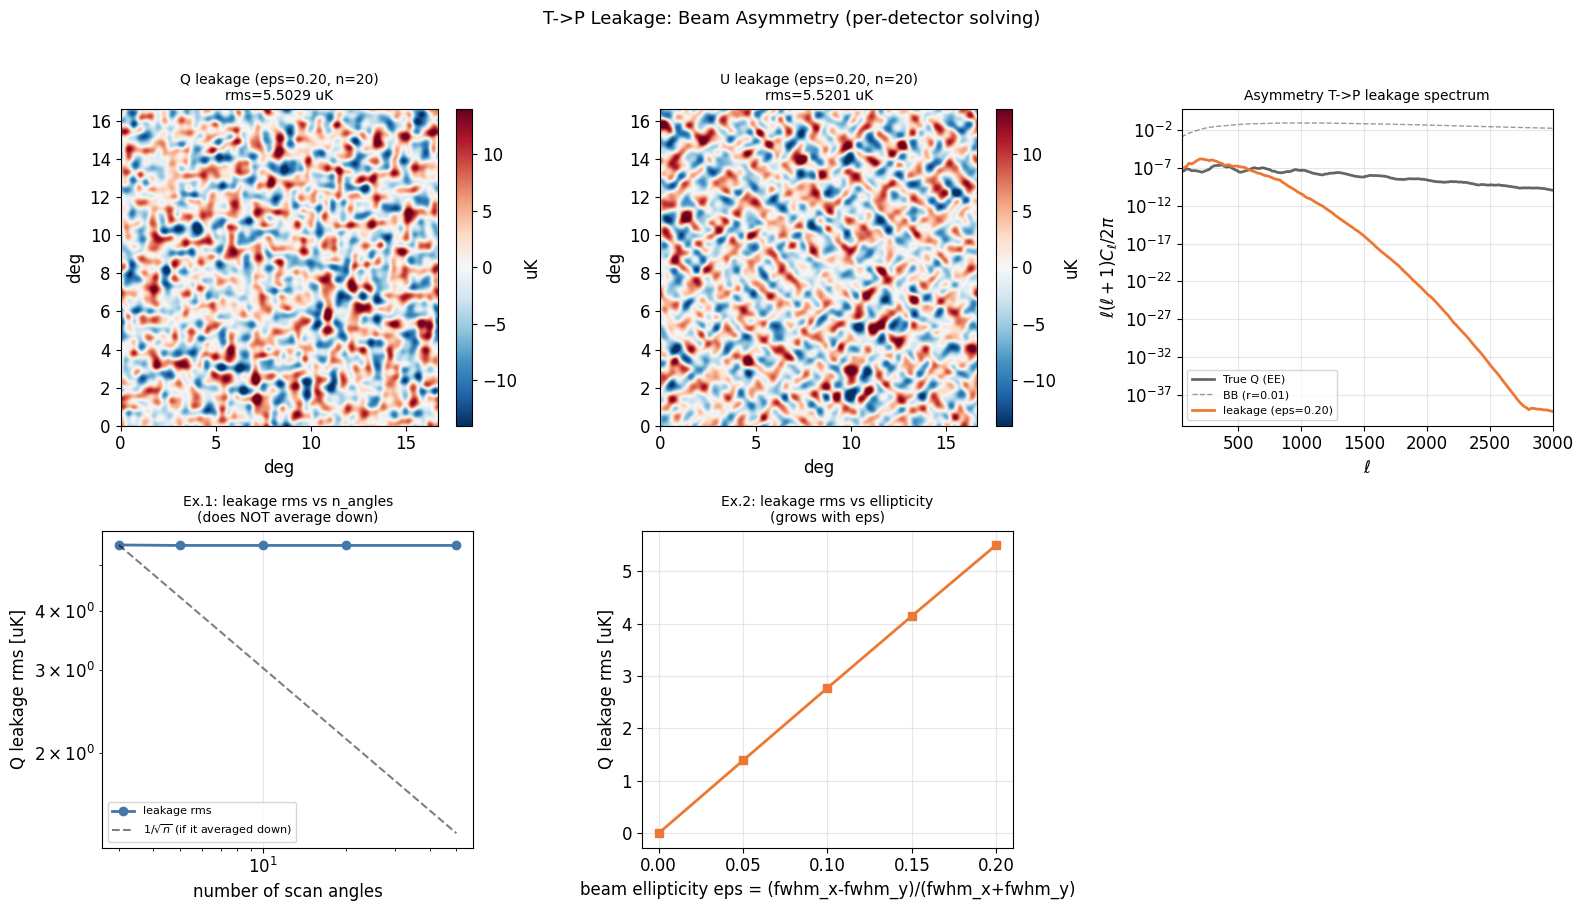

leakage rms vs n_angles (uK): {3: 5.51563, 5: 5.50276, 10: 5.50293, 20: 5.50293, 50: 5.50293}
leakage rms vs ellipticity (uK): {0.0: 0.0, 0.05: 1.38972, 0.1: 2.77382, 0.15: 4.14673, 0.2: 5.50293}


In [16]:
FT_T = np.fft.fft2(np.fft.fftshift(cmb_T))

def leakage_QU(n_angles, fwhm_x, fwhm_y):
    """Q,U leakage from an elliptical beam observed at n_angles scan angles,
    on the full N x N map.  FT_T is precomputed outside the loop."""
    psi = np.linspace(0, np.pi, n_angles, endpoint=False)   # scan angles in [0, pi)
    Q = np.zeros((N, N)); U = np.zeros((N, N))
    for p in psi:
        beam_p = make_2d_elliptical_gaussian_beam(N, pix_size, fwhm_x, fwhm_y, np.degrees(p))
        FT_b = np.fft.fft2(np.fft.fftshift(beam_p))
        d = np.fft.ifftshift(np.fft.ifft2(FT_T * FT_b).real)   # T (conv) B_psi
        Q += d * np.cos(2 * p)
        U += d * np.sin(2 * p)
    Q *= 2.0 / n_angles
    U *= 2.0 / n_angles
    return Q, U

# Ellipticity -> (fwhm_x, fwhm_y) keeping the mean FWHM = fwhm_nom, so that
# eps = (fwhm_x - fwhm_y)/(fwhm_x + fwhm_y) exactly.
def ell_to_fwhm(eps):
    return fwhm_nom * (1 + eps), fwhm_nom * (1 - eps)

_cache = {}
def leakage_cached(n_angles, eps, tag=''):
    key = (n_angles, round(float(eps), 4))
    if key not in _cache:
        if tag:
            print(f"  computing {tag}: n_angles={n_angles}, eps={eps:.2f}", flush=True)
        _cache[key] = leakage_QU(n_angles, *ell_to_fwhm(eps))
    return _cache[key]

eps0 = 0.20   # the ellipticity used earlier in the notebook
n_ang_base = 20

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ax = axes.ravel()

# --- subplots 1-3: baseline leakage at eps=0.20, n_angles=base ---
print("baseline:", flush=True)
Q0, U0 = leakage_cached(n_ang_base, eps0, 'baseline')

v = np.percentile(np.abs(Q0), 99)
im = ax[0].imshow(Q0, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v,
                  extent=[0, N*pix_size/60, 0, N*pix_size/60])
ax[0].set_title(f'Q leakage (eps={eps0:.2f}, n={n_ang_base})\nrms={Q0.std():.4f} uK', fontsize=10)
ax[0].set_xlabel('deg'); ax[0].set_ylabel('deg'); plt.colorbar(im, ax=ax[0], fraction=0.046, label='uK')

im = ax[1].imshow(U0, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v,
                  extent=[0, N*pix_size/60, 0, N*pix_size/60])
ax[1].set_title(f'U leakage (eps={eps0:.2f}, n={n_ang_base})\nrms={U0.std():.4f} uK', fontsize=10)
ax[1].set_xlabel('deg'); ax[1].set_ylabel('deg'); plt.colorbar(im, ax=ax[1], fraction=0.046, label='uK')

ell_q, cl_q = cmb_modules.calculate_2d_spectrum(Q0, Q0, delta_ell, ell_max, pix_size, N)
ell_ee, cl_ee = cmb_modules.calculate_2d_spectrum(Q_sky, Q_sky, delta_ell, ell_max, pix_size, N)
ax[2].semilogy(ell_ee, cl_ee, 'k-', lw=2, alpha=0.6, label='True Q (EE)')
ax[2].semilogy(ell_th[2:], BB_th[2:], 'k--', lw=1, alpha=0.4, label='BB (r=0.01)')
ax[2].semilogy(ell_q, cl_q, lw=2, color=colors[1], label=f'leakage (eps={eps0:.2f})')
ax[2].set_xlabel(r'$\ell$'); ax[2].set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
ax[2].set_title('Asymmetry T->P leakage spectrum', fontsize=10)
ax[2].legend(fontsize=8); ax[2].grid(True, alpha=0.3); ax[2].set_xlim(50, 3000)

# --- EXERCISE 1: leakage rms vs number of observed angles (4th subplot) ---
print("exercise 1: rms vs n_angles", flush=True)
n_angles_list = [3, 5, 10, 20, 50]
rms_vs_n = [leakage_cached(n, eps0, f'ex1 n={n}')[0].std() for n in n_angles_list]

ax[3].loglog(n_angles_list, rms_vs_n, 'o-', lw=2, color=colors[0], label='leakage rms')
# Reference: uncorrelated noise would average down like 1/sqrt(n)
ax[3].loglog(n_angles_list, rms_vs_n[0]*(np.array(n_angles_list, float)/n_angles_list[0])**(-0.5),
             'k--', alpha=0.5, label=r'$1/\sqrt{n}$ (if it averaged down)')
ax[3].set_xlabel('number of scan angles'); ax[3].set_ylabel('Q leakage rms [uK]')
ax[3].set_title('Ex.1: leakage rms vs n_angles\n(does NOT average down)', fontsize=10)
ax[3].legend(fontsize=8); ax[3].grid(True, alpha=0.3)

# --- EXERCISE 2: leakage rms vs ellipticity (5th subplot) ---
print("exercise 2: rms vs ellipticity", flush=True)
eps_list = np.array([0.0, 0.05, 0.10, 0.15, 0.20])
rms_vs_eps = [leakage_cached(n_ang_base, e, f'ex2 eps={e:.2f}')[0].std() for e in eps_list]

ax[4].plot(eps_list, rms_vs_eps, 's-', lw=2, color=colors[1])
ax[4].set_xlabel('beam ellipticity eps = (fwhm_x-fwhm_y)/(fwhm_x+fwhm_y)')
ax[4].set_ylabel('Q leakage rms [uK]')
ax[4].set_title('Ex.2: leakage rms vs ellipticity\n(grows with eps)', fontsize=10)
ax[4].grid(True, alpha=0.3)

ax[5].axis('off')
plt.suptitle('T->P Leakage: Beam Asymmetry (per-detector solving)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("leakage rms vs n_angles (uK):", {n: round(r, 5) for n, r in zip(n_angles_list, rms_vs_n)})
print("leakage rms vs ellipticity (uK):", {round(e, 2): round(r, 5) for e, r in zip(eps_list, rms_vs_eps)})


## T-to-P leakage: Differential Beam Shapes

While pair differencing helps mitigate far sidelobes and other non-idealities, it can also contribute leakage to the polarized signal through the differential properties of the A and B detectors. In a detector pair, detector A sees a beam $B_A = B(\sigma_A)$ and detector B sees $B_B = B(\sigma_B)$. The half-difference map (proportional to Q or U) contains the differential beam $\delta B = (B_A - B_B)/2$ convolved with the temperature map.

## <font color='red'>**EXERCISES**: </font>

##### 1. Assume two detectors with different beam sizes and compute the leakage as above (*again* super simplified projection on Q) for the different delta_fwhm_fractions of 1%, 5% and 10%.
##### 2. Plot the leakage RMS maps / 1D plot as a function of delta_fwhm.
##### 3. Make and plot the leakage spectrum for each delta_fwhm.
##### 4. Optional: Plot the differential beam profile.

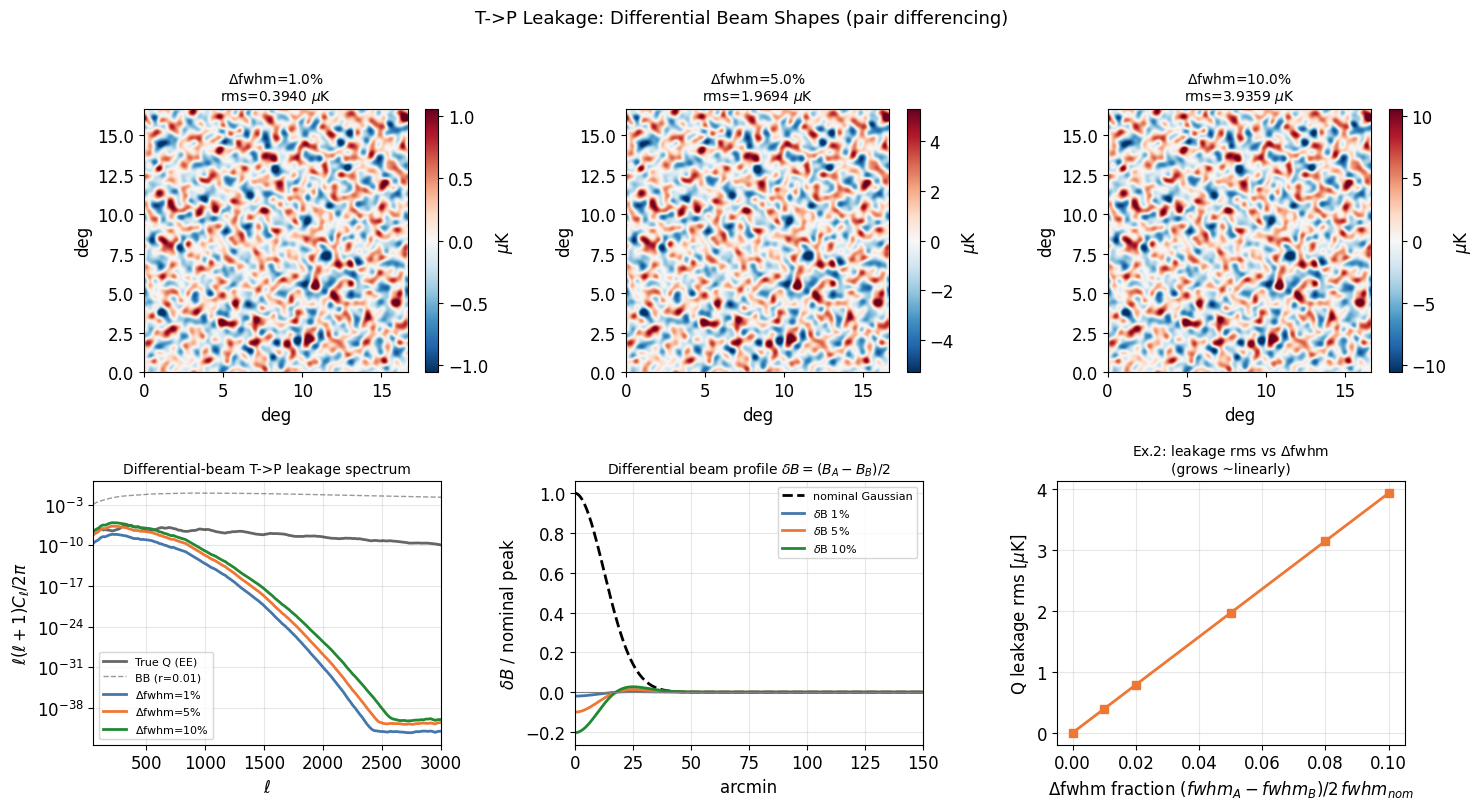

differential-beam leakage rms (uK): {'1%': 0.39399, '5%': 1.96945, '10%': 3.93586}


In [18]:
## T->P leakage: Differential beam shapes (pair differencing).
## A detector pair sees beams B_A = B(fwhm_A) and B_B = B(fwhm_B). The
## half-difference map (-> Q) contains the DIFFERENTIAL beam
##     delta_B = (B_A - B_B)/2  convolved with the temperature map:
##     Q_leak = T (conv) delta_B
## (super-simplified: project the whole residual onto Q, as in the sidelobe cell.)
## Here the FWHM mismatch is parameterised by delta_fwhm_fraction:
##     fwhm_A = fwhm_nom*(1+delta),  fwhm_B = fwhm_nom*(1-delta)
## so the mean FWHM stays fwhm_nom and the half-difference is delta*fwhm_nom.

delta_fwhm_fractions = [0.01, 0.05, 0.10]   # 1%, 5%, 10% FWHM mismatch

def diff_beam(delta):
    """Return (delta_B, B_A, B_B): the differential beam and the two pair beams."""
    fwhm_A = fwhm_nom * (1 + delta)
    fwhm_B = fwhm_nom * (1 - delta)
    B_A = make_2d_gaussian_beam(N, pix_size, fwhm_A)
    B_B = make_2d_gaussian_beam(N, pix_size, fwhm_B)
    return (B_A - B_B) / 2.0, B_A, B_B

# Ex.1: compute the leakage (T convolved with the differential beam) for each delta
P_leak_df = {}
for delta in delta_fwhm_fractions:
    dbeam, _, _ = diff_beam(delta)
    P_leak_df[delta] = convolve_map_with_beam(cmb_T, dbeam)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- row 0: leakage maps (Ex.1) ---
for j, delta in enumerate(delta_fwhm_fractions):
    m = P_leak_df[delta]
    vscale = np.percentile(np.abs(m), 99)
    im = axes[0, j].imshow(m, origin='lower', cmap='RdBu_r', vmin=-vscale, vmax=vscale,
                           extent=[0, N*pix_size/60, 0, N*pix_size/60])
    axes[0, j].set_title(f'$\\Delta$fwhm={delta*100:.1f}%\nrms={m.std():.4f} $\\mu$K', fontsize=10)
    axes[0, j].set_xlabel('deg'); axes[0, j].set_ylabel('deg')
    plt.colorbar(im, ax=axes[0, j], fraction=0.046, label='$\\mu$K')

# --- row1, col0: leakage spectrum for each delta (Ex.3) ---
ell_ee, cl_ee = cmb_modules.calculate_2d_spectrum(Q_sky, Q_sky, delta_ell, ell_max, pix_size, N)
ax = axes[1, 0]
ax.semilogy(ell_ee, cl_ee, 'k-', lw=2, alpha=0.6, label='True Q (EE)')
ax.semilogy(ell_th[2:], BB_th[2:], 'k--', lw=1, alpha=0.4, label='BB (r=0.01)')
for delta, col in zip(delta_fwhm_fractions, colors):
    ell_d, cl_d = cmb_modules.calculate_2d_spectrum(P_leak_df[delta], P_leak_df[delta], delta_ell, ell_max, pix_size, N)
    ax.semilogy(ell_d, cl_d, lw=2, color=col, label=f'$\\Delta$fwhm={delta*100:.0f}%')
ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
ax.set_title('Differential-beam T->P leakage spectrum', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(50, 3000)

# --- row1, col1: differential beam profile (Ex.4, optional) ---
ax = axes[1, 1]
r_amin = r_pix * pix_size
nom_peak = make_2d_gaussian_beam(N, pix_size, fwhm_nom)[cx, cx]
ax.plot(r_amin, radial_cut(make_2d_gaussian_beam(N, pix_size, fwhm_nom), cx), 'k--', lw=2, label='nominal Gaussian')
for delta, col in zip(delta_fwhm_fractions, colors):
    dbeam, _, _ = diff_beam(delta)
    ax.plot(r_amin, dbeam[cx, cx:cx + len(r_amin)] / nom_peak, lw=2, color=col,
            label=f'$\\delta$B {delta*100:.0f}%')
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('arcmin'); ax.set_ylabel(r'$\delta B$ / nominal peak')
ax.set_title('Differential beam profile $\\delta B=(B_A-B_B)/2$', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(0, 5*fwhm_nom)

# --- row1, col2: leakage rms vs delta_fwhm (Ex.2) ---
ax = axes[1, 2]
delta_grid = [0.0, 0.01, 0.02, 0.05, 0.08, 0.10]
rms_grid = []
for d in delta_grid:
    if d in P_leak_df:
        rms_grid.append(P_leak_df[d].std())
    else:
        rms_grid.append(convolve_map_with_beam(cmb_T, diff_beam(d)[0]).std())
ax.plot(delta_grid, rms_grid, 's-', lw=2, color=colors[1])
ax.set_xlabel(r'$\Delta$fwhm fraction $(fwhm_A-fwhm_B)/2\,fwhm_{nom}$')
ax.set_ylabel('Q leakage rms [$\\mu$K]')
ax.set_title('Ex.2: leakage rms vs $\\Delta$fwhm\n(grows ~linearly)', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('T->P Leakage: Differential Beam Shapes (pair differencing)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("differential-beam leakage rms (uK):",
      {f"{d*100:.0f}%": round(P_leak_df[d].std(), 5) for d in delta_fwhm_fractions})


#### Comment

##### T-to-P beam systematics comparison: Identify the correspondence between these three classes of beam systematics. For a fixed leakage RMS of, say, 0.0001 uK, at cosmologically relevant scales, what values of sidelobe fraction, beam ellipticity, and differential FWHM fraction produce the same level of contamination?

## E → B Leakage: Mixing of Polarized Modes

Even in the absence of T→P leakage, beam effects in polarisation maps can mix E and B modes. This is crucial because E-modes are ~100× stronger than B-modes.

The three mechanisms are:
1. **Cross-polarization** — the beam of an A detector also picks up some polarisation from the B orientation (and vice versa), contaminating Q/U
2. **Polarized beam sidelobes**
3. **Polarized beam asymmetry**

## E-to-B leakage: Cross-Polarization

Cross-polarization means that each detector is not purely sensitive to one polarisation state. A detector nominally measuring Q actually measures:
$$Q_\mathrm{meas} = (1 - \gamma) Q_\mathrm{sky} + \gamma U_\mathrm{sky}$$
where $\gamma$ is the cross-polarization fraction (leakage from U into Q). This mixes E and B modes in a well-defined way.

In [18]:
def QU2EB(N, pix_size, Qmap, Umap):
    """Calculate E, B maps given input Stokes Q, U maps (flat sky)."""

    # Create 2d Fourier coordinate system.
    ones = np.ones(N)
    inds = (np.arange(N) - N/2.) / (N - 1.)
    kX = np.outer(ones, inds) / (pix_size/60. * np.pi/180.)
    kY = np.transpose(kX)
    ang = np.arctan2(kY, kX)

    # Convert to Fourier domain.
    fQ = np.fft.fftshift(np.fft.fft2(Qmap))
    fU = np.fft.fftshift(np.fft.fft2(Umap))

    # Convert Q, U to E, B in Fourier domain.
    fE =  fQ * np.cos(2.*ang) + fU * np.sin(2.*ang)
    fB = -fQ * np.sin(2.*ang) + fU * np.cos(2.*ang)

    # Convert E, B from Fourier to real space.
    Emap = np.real(np.fft.ifft2(np.fft.fftshift(fE)))
    Bmap = np.real(np.fft.ifft2(np.fft.fftshift(fB)))

    return Emap, Bmap


# Recover E and B from the true sky
E_sky, B_sky = QU2EB(N, pix_size, Q_sky, U_sky)

ell_bb_true, cl_bb_true = get_ps(B_sky)
ell_ee_true, cl_ee_true = get_ps(E_sky)

print(f"\nTrue sky E rms: {E_sky.std():.4f} μK")
print(f"True sky B rms: {B_sky.std():.4f} μK")
print(f"E/B ratio: {E_sky.std()/B_sky.std():.1f}")

cross_pol_fracs = [0.01, 0.05, 0.10]  # γ: 1%, 5%, 10%

# Beam-convolve Q and U first (with circular Gaussian)
Q_obs_clean = convolve_map_with_beam(Q_sky, beam_gauss)
U_obs_clean = convolve_map_with_beam(U_sky, beam_gauss)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
tp_xpol = {}

for j, (gamma, col) in enumerate(zip(cross_pol_fracs,colors)):
    Q_xpol = (1 - gamma) * Q_obs_clean + gamma * U_obs_clean
    U_xpol = (1 - gamma) * U_obs_clean + gamma * Q_obs_clean

    E_xpol, B_xpol = QU2EB(N, pix_size, Q_xpol, U_xpol)
    # Excess of B-mode excess due to cross-pol
    dB_xpol = B_xpol - B_sky
    tp_xpol[gamma] = (B_xpol, dB_xpol)

    vscale = np.percentile(np.abs(dB_xpol), 99)
    im = axes[0, j].imshow(dB_xpol, origin='lower', cmap='RdBu_r',
                           vmin=-vscale, vmax=vscale,
                           extent=[0, N*pix_size/60, 0, N*pix_size/60])
    axes[0, j].set_title(f'γ = {gamma*100:.0f}%\nΔB rms = {dB_xpol.std():.4f} μK', fontsize=10)
    axes[0, j].set_xlabel('deg'); axes[0, j].set_ylabel('deg')
    plt.colorbar(im, ax=axes[0, j], fraction=0.046, label='μK')

# Power spectra w. cross-pol
ax_x1 = axes[1, 0]
ax_x1.semilogy(ell_bb_true, cl_bb_true, 'k-', lw=2, label='True BB', alpha=0.7)
ax_x1.semilogy(ell_th[2:], BB_th[2:], 'k--', lw=1, alpha=0.4, label='Theory BB (r=0.01)')
for gamma, col in zip(cross_pol_fracs, colors):
    B_xp = tp_xpol[gamma][0]
    ell_xp, cl_xp = get_ps(B_xp)
    ax_x1.semilogy(ell_xp, cl_xp, color=col, lw=2, label=f'γ={gamma*100:.0f}%')
ax_x1.set_xlabel(r'$\ell$'); ax_x1.set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$')
ax_x1.set_title('Recovered BB with Cross-Pol', fontsize=10)
ax_x1.legend(fontsize=8); ax_x1.grid(True, alpha=0.3); ax_x1.set_xlim(50, 3000)

fig.subplots_adjust(wspace=0.3, hspace=0.5)

# ΔB spectrum
ax_x2 = axes[1, 1]
for gamma, col in zip(cross_pol_fracs, colors):
    dB_xp = tp_xpol[gamma][1]
    ell_db, cl_db = get_ps(dB_xp)
    ax_x2.semilogy(ell_db, cl_db, color=col, lw=2, label=f'γ={gamma*100:.0f}%')
ax_x2.semilogy(ell_th[2:], BB_th[2:], 'k--', lw=1.5, alpha=0.5, label='BB (r=0.01)')
ax_x2.set_xlabel(r'$\ell$'); ax_x2.set_ylabel(r'$\ell(\ell+1)\Delta C_\ell^{BB}/2\pi$')
ax_x2.set_title('E→B leakage from Cross-Pol', fontsize=10)
ax_x2.legend(fontsize=8); ax_x2.grid(True, alpha=0.3); ax_x2.set_xlim(50, 3000)


# # Scaling with γ²
## Your code goes here

NameError: name 'get_ps' is not defined

## <font color='red'>**EXERCISE**: </font>


##### Estimate and plot (add to the 5th subplot) the leakage RMS as a function of gamma (cross-pol fraction). How does it scale with cross-pol fraction? Can you fit a polynomial to it?

## E-to-B leakage: Polarized sidelobes

If the far sidelobes of the two orthogonal polarization channels differ, the beam response becomes polarization-dependent. This can cause spurious $E$- and $B$-mode contamination.

##### Optional exercise. Make the same plots as in the temperature beam sidelobe case: compute leakage RMS for different sidelobe amplitude fractions, the corresponding BB spectra, and E-to-B spectra. You can even compare the latter with the T-to-P spectra with the same assumed sidelobe fraction

### E-to-B leakage: Polarized Beam Asymmetry

An asymmetric beam for polarized detectors produces a different
$𝐸$ → $𝐵$ leakage than a symmetric beam. For an elliptical beam, the leakage depends on the relative angle between the beam’s major axis and the Fourier mode direction, with the leading anisotropic term having quadrupolar symmetry (see figure below). In Fourier space, this can generate $E$/$B$ mixing whose amplitude scales with beam ellipticity and whose sign depends on orientation.

<img src="https://drive.google.com/file/d/1FRE1GcI5a1J9jU8Oe9HRVFLOHGlyjON-/view?usp=drive_link" width="700">

##### Optional exercise. Assume Q, U beams with different ellipticity and make the same plots as in the temperature beam asymmetry case: compute leakage RMS for different $\varepsilon$, the corresponding BB spectra, and E-to-B spectra. Look at the 2D leakage in Fourier spectra to see the classic quadrupolar pattern.

In [19]:
PS_NORM = 4.0 * N**2 * (pix_size / 60.0 * np.pi / 180.0)

def get_ps(map1, map2=None, delta_ell=80, ell_max=5000, ell_min=50):
    """Azimuthally averaged D_ell = l(l+1)C_l/2pi  [uK^2].

    Auto-spectrum if map2 is None, otherwise the map1 x map2 cross-spectrum.
    """
    if map2 is None:
        map2 = map1
    ell, Cl = cmb_modules.calculate_2d_spectrum(
        map1, map2, delta_ell, ell_max, pix_size, N)
    Cl = Cl * PS_NORM
    good = (ell >= ell_min) & np.isfinite(Cl)
    ell, Cl = ell[good], Cl[good]
    return ell, Cl * ell * (ell + 1) / (2.0 * np.pi)